# Mobile App A/A/B Test: Checkout Funnel Conversion Analysis

**Business case | E-commerce / Food delivery mobile app**

## 1. Business context

A food-service company is considering a redesign of its mobile app — specifically new fonts across the whole application. Before rolling the change out to all users, the product team ran a controlled experiment: users were randomly assigned to one of three groups.

- **Group 246 — Control (A):** old app design.
- **Group 247 — Control (A′):** old app design (a second control group, used to validate the randomization itself).
- **Group 248 — Test (B):** new app design (new fonts).

Having **two control groups (A and A′)** is a standard experimental-design safeguard: before trusting any A-vs-B comparison, we first confirm that A and A′ — which received the *same* experience — behave the same way. If they don't, the randomization or the measurement pipeline has a problem, and any A-vs-B conclusion would be unreliable.

## 2. Business questions

1. Where in the purchase funnel do users drop off the most, and is that expected?
2. Were users randomly and evenly split across the three groups (i.e., is the A/A comparison "clean")?
3. Does the new design (group B) produce a statistically significant change in conversion to purchase, compared to the old design?
4. Is it worth investing further engineering and design effort in shipping this redesign?

## 3. Dataset

`logs_exp_us.csv` is an event log with **244,126 rows**, one row per user action inside the app:

| Column | Business meaning |
|---|---|
| `EventName` | The action the user performed (e.g., opened the main screen, viewed offers, added to cart, completed payment) |
| `DeviceIDHash` | Anonymized unique identifier of the user's device |
| `EventTimestamp` | Unix timestamp of when the event happened |
| `ExpId` | Experiment group the user belongs to: `246` (A), `247` (A′), `248` (B) |

## 4. Methodology

1. **Data preparation** — load the log, standardize column names, remove duplicate records, and parse timestamps.
2. **Data quality checks** — measure event volume, confirm the useful observation window, and verify every user belongs to exactly one experiment group.
3. **Funnel analysis** — measure how many users reach each step of the conversion funnel (`MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful`) and where the biggest drop-offs happen.
4. **Statistical testing (A/A/B)** — use the Mann-Whitney U test to check, first, that the two control groups are statistically indistinguishable (validating the experiment setup), and then that the test group does not differ significantly from the controls.
5. **Multiple-comparisons correction** — apply a Bonferroni-style correction, since running 4 pairwise tests inflates the chance of a false positive.
6. **Conclusion & recommendation** — translate the statistical result into a go/no-go recommendation for the redesign.


## 5. Environment setup

Standard analysis stack: `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualization, and `scipy.stats` for the Mann-Whitney U hypothesis test used to compare the experiment groups.

In [1]:
# Import libraries (tool boxes for data analysis)
import pandas as pd
import numpy as np
import math as mt
import scipy.stats as st
from scipy.stats import mannwhitneyu
import seaborn as sns
from matplotlib import pyplot as plt

## 6. Step 1 — Load the data and prepare it for analysis

We load the tab-separated event log, inspect its structure, remove exact duplicate rows (repeated log entries that would otherwise double-count events), rename the columns to clean, English, snake_case names, and convert the raw Unix timestamp into a proper datetime column.

In [2]:
# Step 1: Open the data file and read the general information
# Step 2: Prepare the data for analysis

data = pd.read_csv('logs_exp_us.csv', sep="\t")  # tab-separated CSV file
print(data.info())
print(data.head())
print("Duplicated rows:", data.duplicated().sum())
data.drop_duplicates(inplace=True)
print("Duplicated rows after drop_duplicates:", data.duplicated().sum())
print("Null values per column:\n", data.isnull().sum())

# Rename columns to clean, English, snake_case names
data.columns = ['event', 'user_id', 'ts', 'exp_id']

# Convert the Unix timestamp into a proper datetime column
data['date_time'] = pd.to_datetime(data['ts'], unit='s')
data['date'] = data['date_time'].dt.date
print(data.head())

<class 'pandas.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   EventName       244126 non-null  str  
 1   DeviceIDHash    244126 non-null  int64
 2   EventTimestamp  244126 non-null  int64
 3   ExpId           244126 non-null  int64
dtypes: int64(3), str(1)
memory usage: 7.5 MB
None
                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248
Duplicated rows: 413
Duplicated rows after drop_duplicates: 0
Null values per column:
 EventName         0
DeviceIDHash      0
EventTimestamp    0
ExpId        

**Data quality summary.** The log contains no missing values. **413 exact duplicate rows** were found and removed — these are almost certainly repeated log writes rather than genuine repeated user actions, and keeping them would have artificially inflated event counts. The timestamp column was converted into a proper `datetime`, which is required for the time-based filtering and funnel analysis in the next steps.

## 7. Step 2 — Explore and validate the data

Before building the funnel, we check: how many distinct event types exist, how many total events and unique users we have, and — critically for an experiment — whether every user was assigned to **exactly one** experiment group (a user appearing in two groups would break the randomization and bias the results).

We also inspect the distribution of events over time to identify the period where data collection was actually stable, since early, sparse days would otherwise distort the funnel and the statistical tests.

Number of distinct event types: 5
Total events: 243713
Average events per user: 32.28
Number of unique users: 7551
Number of events per event type:
 event
MainScreenAppear           119101
OffersScreenAppear          46808
CartScreenAppear            42668
PaymentScreenSuccessful     34118
Tutorial                     1018
Name: count, dtype: int64
<StringArray>
[       'MainScreenAppear', 'PaymentScreenSuccessful',
        'CartScreenAppear',      'OffersScreenAppear']
Length: 4, dtype: str
Data period: from 2019-07-25 to 2019-08-07
Total logged duration (days): 13 days 16:31:41
Events excluded by the time filter: 792
Number of unique users per group: exp_id
246    2488
247    2519
248    2540
Name: user_id, dtype: int64
Users assigned to more than one group: 0


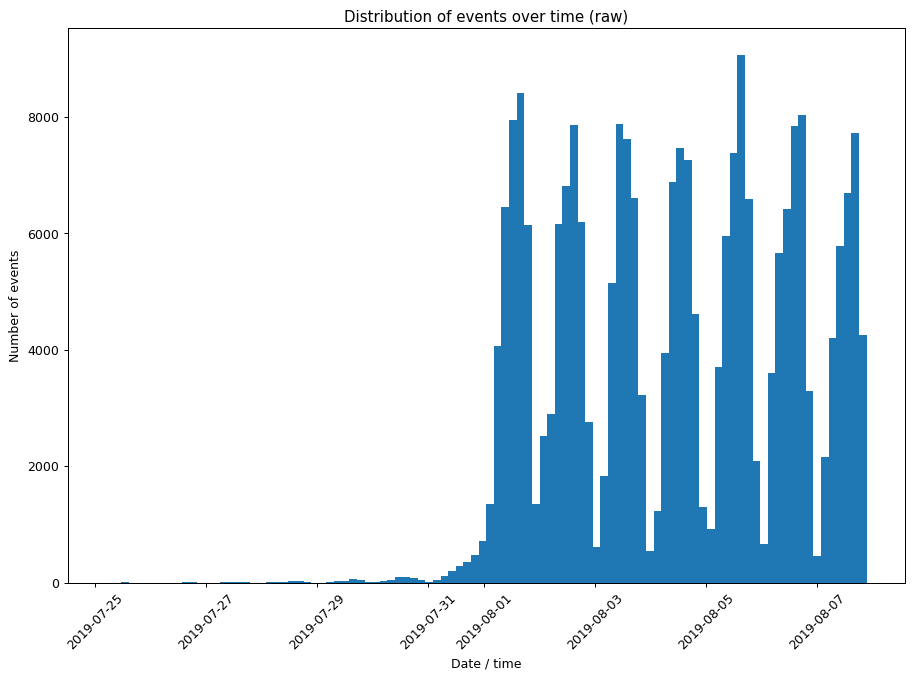

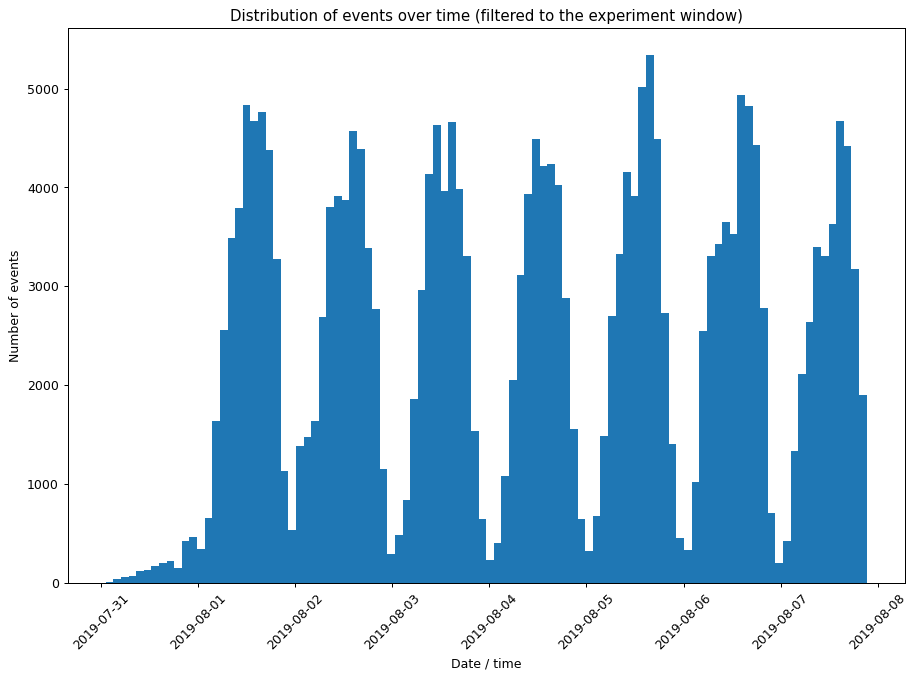

In [3]:
# Step 3: Study and check the data
print("Number of distinct event types:", data['event'].value_counts().count())
total_events = data['event'].count()
print("Total events:", total_events)
unique_users = data['user_id'].nunique()
print("Average events per user:", round(total_events / unique_users, 2))
print("Number of unique users:", unique_users)
print("Number of events per event type:\n", data['event'].value_counts())

# Remove the "Tutorial" event: it is an onboarding step, not a logical
# step of the purchase funnel we are analyzing
data = data.query('event != "Tutorial"')
print(data['event'].unique())
print("Data period: from", data['date'].min(), "to", data['date'].max())
print("Total logged duration (days):", data['date_time'].max() - data['date_time'].min())

# Histogram: raw event distribution over time
plt.figure(figsize=(12, 8))
plt.hist(data['date_time'], bins=100)
plt.title('Distribution of events over time (raw)')
plt.xlabel('Date / time')
plt.ylabel('Number of events')
plt.xticks(rotation=45)
plt.show()

# Filter out the early period with very sparse, unreliable data
data_filtered = data.query('date_time >= "2019-07-30 23:59"').copy()

# Histogram: filtered event distribution over time
plt.figure(figsize=(12, 8))
plt.hist(data_filtered['date_time'], bins=100)
plt.title('Distribution of events over time (filtered to the experiment window)')
plt.xlabel('Date / time')
plt.ylabel('Number of events')
plt.xticks(rotation=45)
plt.show()

print("Events excluded by the time filter:", data.query('date_time <= "2019-07-31 00:00"').shape[0])

# Confirm we have data for the 2 control groups and 1 test group (A / A' / B)
group_sizes = data.groupby('exp_id')['user_id'].nunique()
print("Number of unique users per group:", group_sizes)

# Verify no user appears in more than one experiment group
groups_per_user = data.groupby('user_id')['exp_id'].nunique()
users_in_multiple_groups = groups_per_user[groups_per_user > 1]
print("Users assigned to more than one group:", len(users_in_multiple_groups))

**Reading the data-quality checks.** The full log spans **July 25 to August 7, 2019**, but the first histogram shows very few events before end of July — an artifact of when logging was switched on, not real user behavior. Using data from that sparse period would understate early-funnel volumes and could bias the statistical tests, so we restrict the analysis to the **stable window starting July 31, 23:59 through August 7** (8 days of reliable data), discarding **792 events** (about 0.3% of the log) that fall outside it.

After filtering, every user is confirmed to belong to **exactly one** of the three experiment groups (246 / 247 / 248), with roughly **2,500 users per group** — a well-balanced three-way split, which is a good sign for the integrity of the randomization.

## 8. Step 3 — Build and analyze the conversion funnel

We now build the purchase funnel: `MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful`. For each step we count **unique users** (not raw events, since a single user can trigger the same event multiple times), split by experiment group, and compute the step-to-step conversion rate to find where the biggest drop-offs happen.

In [4]:
# Step 4: Study the event funnel

# Total events remaining after cleaning
print("Total events after cleaning:\n", data['event'].count())

# Unique users per event type (across all groups)
print("Unique users per event type:", data.groupby('event')['user_id'].nunique().sort_values(ascending=False))

# Note: the "Tutorial" event was already excluded in Step 2, since it is an
# onboarding step and not a logical part of the purchase funnel.

# Funnel table split by experiment group
funnel = data.pivot_table(
    index="event",
    columns="exp_id",
    values="user_id",
    aggfunc="nunique"
).sort_values(by=246, ascending=False)
print(funnel)

# Step-to-step conversion rate within the funnel
funnel_percent = round((funnel / funnel.shift() * 100), 2)
print(funnel_percent)

Total events after cleaning:
 242695
Unique users per event type: event
MainScreenAppear           7439
OffersScreenAppear         4613
CartScreenAppear           3749
PaymentScreenSuccessful    3547
Name: user_id, dtype: int64
exp_id                    246   247   248
event                                    
MainScreenAppear         2456  2482  2501
OffersScreenAppear       1545  1530  1538
CartScreenAppear         1270  1240  1239
PaymentScreenSuccessful  1202  1160  1185
exp_id                     246    247    248
event                                       
MainScreenAppear           NaN    NaN    NaN
OffersScreenAppear       62.91  61.64  61.50
CartScreenAppear         82.20  81.05  80.56
PaymentScreenSuccessful  94.65  93.55  95.64


**Funnel finding.** The biggest single drop-off in the entire purchase funnel happens between **`MainScreenAppear`** and **`OffersScreenAppear`**, where the company loses roughly **37–38.5%** of users, consistently across all three groups. This is expected in most e-commerce/app funnels: this is the step where a visitor is first shown something to buy, and a meaningful share of casual visitors — who were just browsing — naturally drop off here rather than proceeding toward a purchase.

In [5]:
# Step 4.6: Overall conversion rate per group, from first screen to successful payment

conversion_246 = round((funnel.loc['PaymentScreenSuccessful', 246] / funnel.loc['MainScreenAppear', 246]) * 100, 2)
conversion_247 = round((funnel.loc['PaymentScreenSuccessful', 247] / funnel.loc['MainScreenAppear', 247]) * 100, 2)
conversion_248 = round((funnel.loc['PaymentScreenSuccessful', 248] / funnel.loc['MainScreenAppear', 248]) * 100, 2)

print(f"Overall conversion, group 246 (A): {conversion_246}%")
print(f"Overall conversion, group 247 (A'): {conversion_247}%")
print(f"Overall conversion, group 248 (B): {conversion_248}%")

Overall conversion, group 246 (A): 48.94%
Overall conversion, group 247 (A'): 46.74%
Overall conversion, group 248 (B): 47.38%


## 9. Step 4 — Statistical testing of the experiment (A/A/B)

**Why a non-parametric test.** User-level conversion is a binary outcome (converted / did not convert), so we compare groups using the **Mann-Whitney U test**, a non-parametric test that does not assume the underlying data is normally distributed — appropriate here since we are comparing 0/1 conversion arrays, not continuous, normally distributed metrics.

**Testing order matters.** We first compare the two **control** groups (A vs. A′). If they show a statistically significant difference despite having received the *identical* experience, that would indicate a flaw in the randomization or measurement pipeline, and any A-vs-B conclusion downstream would not be trustworthy. Only after confirming A ≈ A′ do we move on to comparing the test group (B) against the controls.

In [6]:
# Step 5: Study the results of the experiment

# 5.1 Confirm sample size per group
print("Number of users per test group (exp_id):", data.groupby('exp_id')['user_id'].nunique())

# 5.2 Build a binary conversion array (1 = converted, 0 = did not convert) per user, per group
def build_conversion_array(exp_id):
    # Unique users who were exposed to this experiment group
    users_in_group = data[data['exp_id'] == exp_id]['user_id'].unique()
    # Users who converted (reached PaymentScreenSuccessful)
    converted_users = data[(data['exp_id'] == exp_id) & (data['event'] == 'PaymentScreenSuccessful')]['user_id'].unique()
    # Binary array: 1 if the user converted, 0 otherwise
    conversion_array = [1 if user in converted_users else 0 for user in users_in_group]
    return conversion_array

# Build the conversion arrays for each group
group_246 = build_conversion_array(246)
group_247 = build_conversion_array(247)
group_248 = build_conversion_array(248)
groups_246_247_combined = np.concatenate([build_conversion_array(246), build_conversion_array(247)])

# A vs A' Mann-Whitney U test (validation of the experiment setup)
statistic, p_value = mannwhitneyu(group_246, group_247)

print("=== MANN-WHITNEY TEST (Control groups 246 vs 247) ===")
print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value:.6f}")
print(f"Significant difference? {'Yes' if p_value < 0.05 else 'No'}")

Number of users per test group (exp_id): exp_id
246    2488
247    2519
248    2540
Name: user_id, dtype: int64
=== MANN-WHITNEY TEST (Control groups 246 vs 247) ===
Mann-Whitney U statistic: 3204515.0
P-value: 0.108964
Significant difference? No


**A/A validation result.** The Mann-Whitney U test between control group **246 (A)** and control group **247 (A′)** shows **no statistically significant difference**. Since both groups received the exact same (old) app experience, this is the expected and desired result: it confirms the random assignment and group split worked correctly, there is no systematic bias between the groups, and the experiment is validly set up to move on to the real question — testing A and A′ against B.

In [7]:
# A vs B Mann-Whitney U test
statistic, p_value = mannwhitneyu(group_246, group_248)

print("=== MANN-WHITNEY TEST (Groups 246 vs 248) ===")
print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value:.6f}")
print(f"Significant difference? {'Yes' if p_value < 0.05 else 'No'}")
print()
print()

# A' vs B Mann-Whitney U test
statistic, p_value = mannwhitneyu(group_247, group_248)

print("=== MANN-WHITNEY TEST (Groups 247 vs 248) ===")
print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value:.6f}")
print(f"Significant difference? {'Yes' if p_value < 0.05 else 'No'}")
print()
print()

# A + A' (combined controls) vs B Mann-Whitney U test
statistic, p_value = mannwhitneyu(groups_246_247_combined, group_248)

print("=== MANN-WHITNEY TEST (Combined controls 246+247 vs 248) ===")
print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value:.6f}")
print(f"Significant difference? {'Yes' if p_value < 0.05 else 'No'}")

=== MANN-WHITNEY TEST (Groups 246 vs 248) ===
Mann-Whitney U statistic: 3212160.0
P-value: 0.239106
Significant difference? No


=== MANN-WHITNEY TEST (Groups 247 vs 248) ===
Mann-Whitney U statistic: 3179822.5
P-value: 0.666937
Significant difference? No


=== MANN-WHITNEY TEST (Combined controls 246+247 vs 248) ===
Mann-Whitney U statistic: 6391982.5
P-value: 0.668650
Significant difference? No


## 10. Step 5 — Multiple-comparisons correction (Bonferroni)

We ran **4 pairwise tests** in total (A vs A′, A vs B, A′ vs B, and A+A′ vs B). Running several tests on the same experiment inflates the overall chance of a false positive — this is worth checking explicitly rather than assuming a single 5% significance level still applies.

- With a single test at **α = 0.05**, the chance of a false positive is 5%.
- Getting a false positive on **all 4** tests simultaneously by pure chance would require (0.05)⁴ ≈ **0.0006%** — vanishingly unlikely, so it is not a realistic concern here.
- The relevant risk is the **Family-Wise Error Rate (FWER)** — the probability of at least **one** false positive across the 4 tests: 1 − (0.95)⁴ ≈ **18.5%**.
- Applying a **Bonferroni correction** for 4 tests lowers the significance threshold to α = 0.05 / 4 = **1.25%**.

**Result under the corrected threshold.** All 4 observed p-values are far above even the original 5% threshold, let alone the stricter 1.25% Bonferroni threshold:

| Comparison | P-value |
|---|---|
| A vs A′ | 0.108964 |
| A vs B | 0.239106 |
| A′ vs B | 0.666937 |
| A+A′ vs B | 0.668650 |

Since every p-value clears the correction comfortably, the multiple-comparisons adjustment does not change the conclusion: there is **no statistically significant evidence** of a conversion difference between the new design (B) and the old design (A / A′), under either the uncorrected or the Bonferroni-corrected threshold.


## 11. Conclusions & business recommendation

**Funnel.** The purchase funnel loses users primarily at the **`MainScreenAppear → OffersScreenAppear`** step (≈37–38.5%), consistent with normal browsing-to-interest drop-off, and this pattern holds across all three groups.

**A/A validation.** Groups 246 (A) and 247 (A′) — which received the identical old design — show no statistically significant difference in conversion. This confirms the random assignment worked correctly and that there is no systematic bias between groups, so the experiment is valid to test.

**A vs B result.** None of the four pairwise comparisons (A vs A′, A vs B, A′ vs B, combined A+A′ vs B) show a statistically significant difference in conversion to purchase, even after applying a conservative Bonferroni correction for running multiple tests. In other words: **the new app design (new fonts) does not produce a measurable change — positive or negative — in checkout conversion.**

**Business recommendation.** Since there is no evidence the redesign improves conversion, and a real (if now disproven) concern going into the test was that it might *decrease* conversion, **shipping this redesign purely for a conversion lift is not justified** — it would be an unnecessary expense from a pure conversion standpoint. That said, this test only measured conversion; if the redesign is expected to improve other outcomes not captured here (e.g., brand perception, accessibility, long-term engagement), those would need to be evaluated separately before making a final call. From a conversion-only lens, resources are better spent testing a more substantial change to the `MainScreenAppear → OffersScreenAppear` step, since that is where the funnel loses the most users.
